# 07 — NanoVLM Evaluation

The training stage is complete. We now evaluate whether the NanoVLM learned a useful shared image-text representation.

The main comparison is:

1. **Pre-training:** a freshly initialized NanoVLM with random weights.
2. **Post-training:** the trained NanoVLM loaded from the saved checkpoint.

The key question is:

> Did contrastive training make matching images and captions more similar?

The evaluation flow is:

```text
Image
  ↓
Image Encoder
  ↓
Image Embedding
  │
  ├──────────────→ Similarity
  │
  ↓
Shared 64-D Embedding Space
  ↑
  │
Text Embedding
  ↑
Text Encoder
  ↑
Caption

In [30]:
# ============================================================
# NanoVLM Evaluation — Inputs
# ============================================================

import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

from configs.config import (
    DEVICE,
    CONTEXT_WINDOW,
    EMBED_DIM,
    ATTENTION_HEADS,
    PROJECTION_DIM,
    CHECKPOINT_PATH,
    FIGURES_DIR,
)

# ------------------------------------------------------------
# Tokenizer
# ------------------------------------------------------------

from nano_vlm.data.tokenizer import (
    VOCAB_SIZE,
    PAD_TOKEN_ID,
    tokenize_captions,
)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

from nano_vlm.data.dataset import SyntheticVLDataset

# ------------------------------------------------------------
# Model
# # ------------------------------------------------------------

# from nano_vlm.models.image_encoder import ImageEncoder
# from nano_vlm.models.text_encoder import TextEncoder
from nano_vlm.models.model import NanoVLM

# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

assert CHECKPOINT_PATH.exists(), (
    f"Checkpoint not found:\n{CHECKPOINT_PATH}"
)

print("Device:", DEVICE)
print("Checkpoint:", CHECKPOINT_PATH)
print("✓ Evaluation dependencies loaded.")

Device: cpu
Checkpoint: D:\github\Build A NanoVLM From SCRATCH\checkpoints\nanovlm_checkpoint.pt
✓ Evaluation dependencies loaded.


## 1. Load the Evaluation Data

In [31]:
# ============================================================
# Load existing evaluation data
# ============================================================

DATASET_ARTIFACTS_DIR = (
    PROJECT_ROOT / "artifacts" / "dataset"
)

val_samples_path = (
    DATASET_ARTIFACTS_DIR / "val_samples.pt"
)

assert val_samples_path.exists(), (
    f"Validation samples not found:\n{val_samples_path}"
)

val_samples = torch.load(
    val_samples_path,
    map_location="cpu",
    weights_only=False,
)

val_dataset = SyntheticVLDataset(
    val_samples
)

print("Validation samples:", len(val_dataset))
print("✓ Existing validation dataset loaded.")

Validation samples: 49
✓ Existing validation dataset loaded.


In [32]:
from torch.utils.data import DataLoader

eval_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

print("Evaluation batches:", len(eval_loader))

Evaluation batches: 2


In [33]:
# ============================================================
# Create Evaluation DataLoader
# ============================================================

from torch.utils.data import DataLoader

DATASET_ARTIFACTS_DIR = (
    PROJECT_ROOT / "artifacts" / "dataset"
)

VAL_SAMPLES_PATH = (
    DATASET_ARTIFACTS_DIR / "val_samples.pt"
)

assert VAL_SAMPLES_PATH.exists(), (
    f"Validation samples not found:\n{VAL_SAMPLES_PATH}"
)

# Load the validation samples saved by the dataset notebook
val_samples = torch.load(
    VAL_SAMPLES_PATH,
    map_location="cpu",
    weights_only=False,
)

# Reuse the existing Dataset implementation
val_dataset = SyntheticVLDataset(
    val_samples
)

# Evaluation loader
eval_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

print("Validation samples:", len(val_dataset))
print("Evaluation batches:", len(eval_loader))
print("✓ Evaluation DataLoader ready.")

Validation samples: 49
Evaluation batches: 2
✓ Evaluation DataLoader ready.


## 2. Load Pre-Training and Post-Training Models

We now create two versions of the same NanoVLM architecture.

### Pre-training model

This model is freshly initialized.

Its parameters are random, so it represents what the model looked like before learning from the image-text pairs.

### Post-training model

This model has exactly the same architecture, but its parameters are loaded from:

```text
checkpoints/nanovlm_checkpoint.pt

Random NanoVLM
      ↓
Pre-training representation


Trained NanoVLM
      ↓
Post-training representation

In [34]:
# ============================================================
# Create Pre-Training and Post-Training NanoVLM
# ============================================================

def create_nanovlm():

    return NanoVLM(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        attention_heads=ATTENTION_HEADS,
        context_window=CONTEXT_WINDOW,
        projection_dim=PROJECTION_DIM,
        padding_idx=PAD_TOKEN_ID,
    ).to(DEVICE)


# ------------------------------------------------------------
# PRE-TRAINING MODEL
# Randomly initialized weights
# ------------------------------------------------------------

pre_model = create_nanovlm()


# ------------------------------------------------------------
# POST-TRAINING MODEL
# Load trained NanoVLM checkpoint
# ------------------------------------------------------------

post_model = create_nanovlm()

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

post_model.load_state_dict(
    checkpoint["model_state_dict"]
)


# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

pre_model.eval()
post_model.eval()


print("✓ Random pre-training NanoVLM created.")
print("✓ Trained NanoVLM checkpoint loaded.")

print("\nPre-training model:")
print(pre_model)

print("\nPost-training model:")
print(post_model)

✓ Random pre-training NanoVLM created.
✓ Trained NanoVLM checkpoint loaded.

Pre-training model:
NanoVLM(
  (image_encoder): ImageEncoder(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (global_pool): AdaptiveAvgPool2d(output_size=1)
    (projection): Linear(in_features=256, out_features=64, bias=True)
  )
  (text_encoder): TextEncoder(
    (token_embedding): Embedding(25, 64, padding_idx=0)
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (projection): Linear(in_features=64, out_features=64, bias=True)
  )
)

Post-training model:
NanoVLM(
  (im

In [35]:
import inspect

print(inspect.signature(NanoVLM))
print(inspect.signature(NanoVLM.__init__))
print(inspect.getfile(NanoVLM))

(vocab_size, embed_dim, attention_heads, context_window, projection_dim=64, padding_idx=None)
(self, vocab_size, embed_dim, attention_heads, context_window, projection_dim=64, padding_idx=None)
D:\github\Build A NanoVLM From SCRATCH\src\nano_vlm\models\model.py


In [36]:
# ============================================================
# Same Evaluation Batch
# ============================================================

batch = next(iter(eval_loader))

images = batch["image"]
captions = batch["caption"]

images = images.to(DEVICE)

tokens = tokenize_captions(
    captions,
    max_length=CONTEXT_WINDOW,
).to(DEVICE)

print("Images :", images.shape)
print("Tokens :", tokens.shape)
print("Captions:", len(captions))

assert images.shape[0] == tokens.shape[0]

Images : torch.Size([32, 3, 32, 32])
Tokens : torch.Size([32, 16])
Captions: 32


## 3. Extract Pre-Training and Post-Training Embeddings

We now pass the **exact same batch** through both models.

For each model we obtain:

```text
Images
  ↓
Image Encoder
  ↓
Image Embeddings

In [37]:
# ============================================================
# Extract Pre-Training and Post-Training Embeddings
# ============================================================

with torch.no_grad():

    # --------------------------------------------------------
    # Pre-training
    # --------------------------------------------------------

    pre_image_embeddings = pre_model.encode_image(
        images
    )

    pre_text_embeddings = pre_model.encode_text(
        tokens
    )

    # --------------------------------------------------------
    # Post-training
    # --------------------------------------------------------

    post_image_embeddings = post_model.encode_image(
        images
    )

    post_text_embeddings = post_model.encode_text(
        tokens
    )


# Normalize for cosine similarity

pre_image_embeddings = F.normalize(
    pre_image_embeddings,
    dim=-1,
)

pre_text_embeddings = F.normalize(
    pre_text_embeddings,
    dim=-1,
)

post_image_embeddings = F.normalize(
    post_image_embeddings,
    dim=-1,
)

post_text_embeddings = F.normalize(
    post_text_embeddings,
    dim=-1,
)


print("Pre image :", pre_image_embeddings.shape)
print("Pre text  :", pre_text_embeddings.shape)

print("Post image:", post_image_embeddings.shape)
print("Post text :", post_text_embeddings.shape)

assert pre_image_embeddings.shape[1] == 64
assert post_image_embeddings.shape[1] == 64

Pre image : torch.Size([32, 64])
Pre text  : torch.Size([32, 64])
Post image: torch.Size([32, 64])
Post text : torch.Size([32, 64])


In [38]:
# ============================================================
# Image-Text Similarity
# ============================================================

pre_similarity = (
    pre_image_embeddings
    @ pre_text_embeddings.T
)

post_similarity = (
    post_image_embeddings
    @ post_text_embeddings.T
)

print("Pre-training similarity:", pre_similarity.shape)
print("Post-training similarity:", post_similarity.shape)

# Correct image-caption pairs are on the diagonal

pre_diagonal = torch.diag(pre_similarity)
post_diagonal = torch.diag(post_similarity)

print(
    "\nMean positive similarity:"
)

print(
    "Pre-training :",
    pre_diagonal.mean().item(),
)

print(
    "Post-training:",
    post_diagonal.mean().item(),
)

Pre-training similarity: torch.Size([32, 32])
Post-training similarity: torch.Size([32, 32])

Mean positive similarity:
Pre-training : -0.040344689041376114
Post-training: 0.8731468915939331


## 4. Pre-Training vs Post-Training Alignment

The similarity matrix tells us how strongly every image matches every caption.

For a batch of size $B$:

$$
S \in \mathbb{R}^{B \times B}
$$

The diagonal contains the correct image-caption pairs:

```text
          Captions
       0   1   2   3
     ┌───────────────
Img 0│ ✓
Img 1│     ✓
Img 2│         ✓
Img 3│             ✓

C:\Users\Asim Shah\AppData\Local\Temp\ipykernel_31072\93662133.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


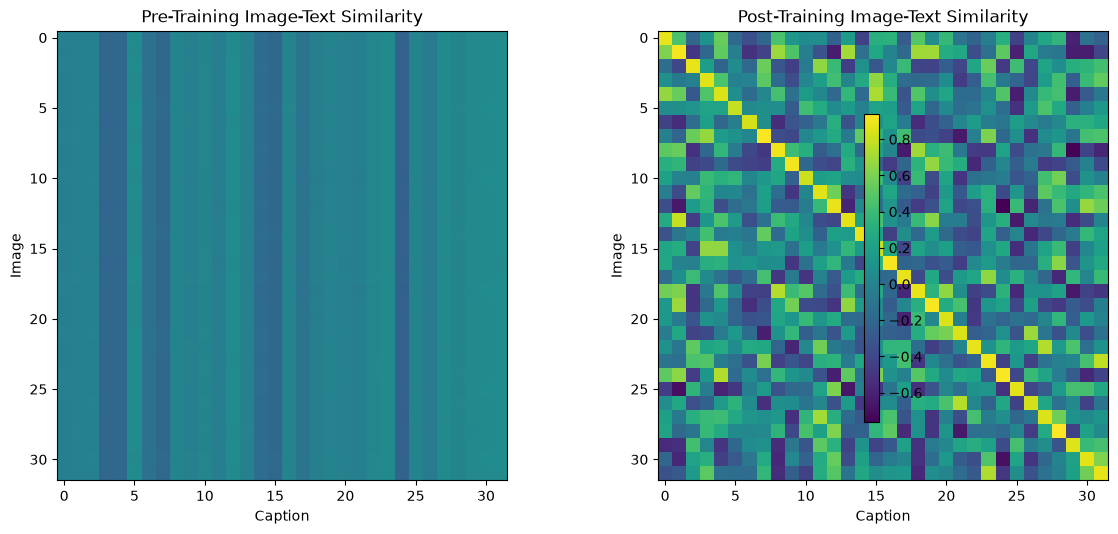

✓ Saved: D:\github\Build A NanoVLM From SCRATCH\artifacts\figures\pre_vs_post_similarity.png


In [39]:
# ============================================================
# Pre vs Post Similarity Matrices
# ============================================================

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

vmin = min(
    pre_similarity.min().item(),
    post_similarity.min().item(),
)

vmax = max(
    pre_similarity.max().item(),
    post_similarity.max().item(),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

im1 = axes[0].imshow(
    pre_similarity.cpu(),
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title(
    "Pre-Training Image-Text Similarity"
)

axes[0].set_xlabel("Caption")
axes[0].set_ylabel("Image")


im2 = axes[1].imshow(
    post_similarity.cpu(),
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title(
    "Post-Training Image-Text Similarity"
)

axes[1].set_xlabel("Caption")
axes[1].set_ylabel("Image")

fig.colorbar(
    im2,
    ax=axes,
    shrink=0.8,
)

plt.tight_layout()

similarity_path = (
    FIGURES_DIR /
    "pre_vs_post_similarity.png"
)

plt.savefig(
    similarity_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("✓ Saved:", similarity_path)

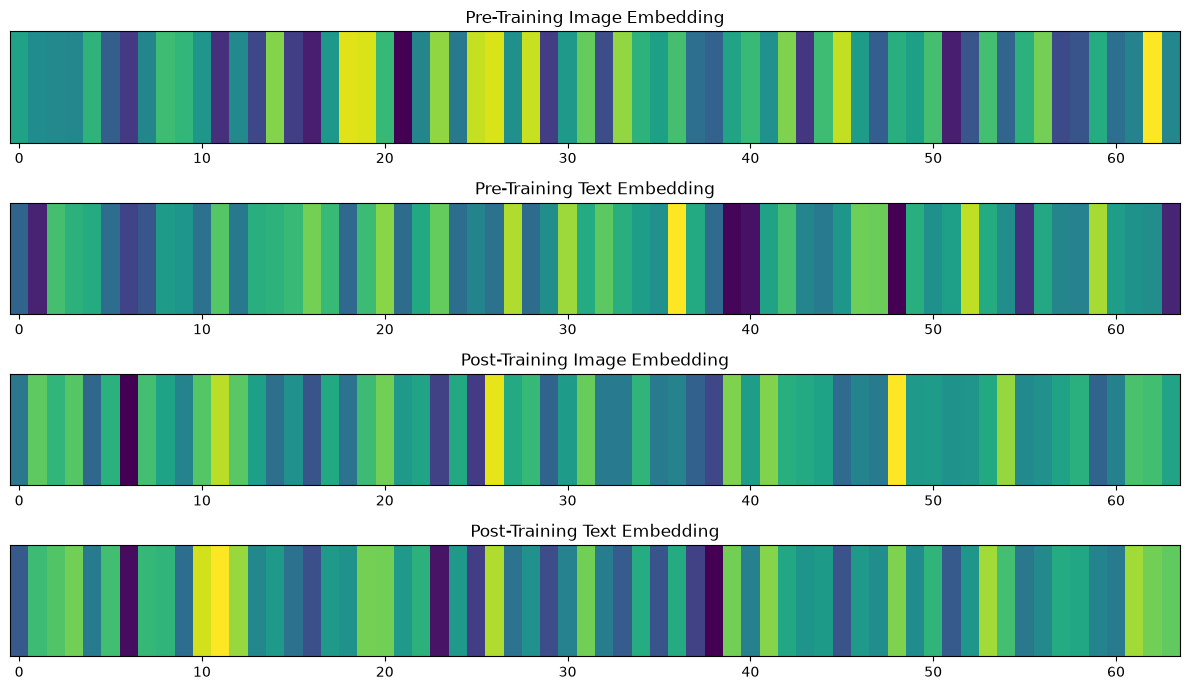

✓ Saved: D:\github\Build A NanoVLM From SCRATCH\artifacts\figures\pre_vs_post_embeddings.png


In [40]:
# ============================================================
# Embedding Vector Comparison
# ============================================================

sample_index = 0

embeddings = [
    pre_image_embeddings[sample_index],
    pre_text_embeddings[sample_index],
    post_image_embeddings[sample_index],
    post_text_embeddings[sample_index],
]

titles = [
    "Pre-Training Image Embedding",
    "Pre-Training Text Embedding",
    "Post-Training Image Embedding",
    "Post-Training Text Embedding",
]

fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, 7),
)

for ax, embedding, title in zip(
    axes,
    embeddings,
    titles,
):

    ax.imshow(
        embedding.detach()
        .cpu()
        .reshape(1, -1),
        aspect="auto",
    )

    ax.set_title(title)
    ax.set_yticks([])

plt.tight_layout()

embedding_path = (
    FIGURES_DIR /
    "pre_vs_post_embeddings.png"
)

plt.savefig(
    embedding_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("✓ Saved:", embedding_path)

In [41]:
# ============================================================
# Image <-> Text Retrieval
# ============================================================

def retrieval_top1(similarity):

    # Image -> Text
    image_to_text = similarity.argmax(
        dim=1
    )

    image_to_text_accuracy = (
        image_to_text
        == torch.arange(
            similarity.shape[0],
            device=similarity.device,
        )
    ).float().mean()

    # Text -> Image
    text_to_image = similarity.T.argmax(
        dim=1
    )

    text_to_image_accuracy = (
        text_to_image
        == torch.arange(
            similarity.shape[0],
            device=similarity.device,
        )
    ).float().mean()

    return (
        image_to_text_accuracy.item(),
        text_to_image_accuracy.item(),
    )


pre_i2t, pre_t2i = retrieval_top1(
    pre_similarity
)

post_i2t, post_t2i = retrieval_top1(
    post_similarity
)


print("=" * 55)
print("RETRIEVAL RESULTS")
print("=" * 55)

print(
    f"{'Metric':<25}"
    f"{'Pre':>10}"
    f"{'Post':>10}"
)

print(
    f"{'Image → Text Top-1':<25}"
    f"{pre_i2t:>10.3f}"
    f"{post_i2t:>10.3f}"
)

print(
    f"{'Text → Image Top-1':<25}"
    f"{pre_t2i:>10.3f}"
    f"{post_t2i:>10.3f}"
)

print("=" * 55)

RETRIEVAL RESULTS
Metric                          Pre      Post
Image → Text Top-1            0.031     1.000
Text → Image Top-1            0.031     1.000


In [42]:
# ============================================================
# Save Evaluation Outputs
# ============================================================

EVALUATION_DIR = (
    PROJECT_ROOT /
    "artifacts" /
    "evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


evaluation_results = {
    "pre_mean_positive_similarity":
        pre_diagonal.mean().item(),

    "post_mean_positive_similarity":
        post_diagonal.mean().item(),

    "pre_image_to_text_top1":
        pre_i2t,

    "post_image_to_text_top1":
        post_i2t,

    "pre_text_to_image_top1":
        pre_t2i,

    "post_text_to_image_top1":
        post_t2i,

    "embedding_dimension":
        pre_image_embeddings.shape[-1],
}


torch.save(
    evaluation_results,
    EVALUATION_DIR /
    "evaluation_results.pt",
)


print("=" * 60)
print("NanoVLM Evaluation Summary")
print("=" * 60)

print(
    "Pre positive similarity :",
    evaluation_results[
        "pre_mean_positive_similarity"
    ],
)

print(
    "Post positive similarity:",
    evaluation_results[
        "post_mean_positive_similarity"
    ],
)

print(
    "Pre Image → Text Top-1 :",
    evaluation_results[
        "pre_image_to_text_top1"
    ],
)

print(
    "Post Image → Text Top-1:",
    evaluation_results[
        "post_image_to_text_top1"
    ],
)

print(
    "Pre Text → Image Top-1 :",
    evaluation_results[
        "pre_text_to_image_top1"
    ],
)

print(
    "Post Text → Image Top-1:",
    evaluation_results[
        "post_text_to_image_top1"
    ],
)

print(
    "\nEmbedding dimension:",
    evaluation_results[
        "embedding_dimension"
    ],
)

print("=" * 60)
print("✓ NanoVLM evaluation complete.")

NanoVLM Evaluation Summary
Pre positive similarity : -0.040344689041376114
Post positive similarity: 0.8731468915939331
Pre Image → Text Top-1 : 0.03125
Post Image → Text Top-1: 1.0
Pre Text → Image Top-1 : 0.03125
Post Text → Image Top-1: 1.0

Embedding dimension: 64
✓ NanoVLM evaluation complete.
